We import JuMag and use double float precision in the simulation

In [1]:
using JuMag
using NPZ
JuMag.cuda_using_double(true)

In this example, the studied system is a round nanodisk. Since we are using finite different method,
we create a FDMesh with dimensions 200nm x 200nm x 20 nm.

In [2]:
mesh =  FDMeshGPU(dx=2e-9, dy=2e-9, dz=5e-9, nx=100, ny=100, nz=4)

FDMeshGPU{Float64}(2.0e-9, 2.0e-9, 5.0e-9, 100, 100, 4, 40000, false, false, false, 2.0e-26)

The shape of the studied system can be controlled by setting a zero Ms in the unnecessary region.
Here we defined a function that return a nonzero Ms within the circle and otherwise return zero.
This function should take six parameters `(i,j,k,dx,dy,dz)`.

In [3]:
function circular_Ms(i,j,k,dx,dy,dz)
    x = i-50.5
    y = j-50.5
    r = (x^2+y^2)^0.5
    if (i-50.5)^2 + (j-50.5)^2 <= 50^2
        return 8e5
    end
    return 0.0
end

circular_Ms (generic function with 1 method)

To start the simulation, we need to give an initial state.
Here we use a function to give the initial state.

In [4]:
function init_fun(i,j,k,dx,dy,dz)
  x = i-50.5
  y = j-50.5
  r = (x^2+y^2)^0.5
  if r<20
    return (0,0,1)
  end
  return (y/r, -x/r, 0)
end

init_fun (generic function with 1 method)

We use a function to collect the necessary definition of this problem.

In [5]:
function relax_system(mesh)
  #We create a simulation
  sim = Sim(mesh, driver="SD", name="sim")

  #Set the saturation magnetization and define the geometry as well.
  set_Ms(sim, circular_Ms)

  #We add the exchange interaction and the demagnetization field to the system.
  add_exch(sim, 1.3e-11, name="exch")
  add_demag(sim)

  #Initialize the system using the `init_fun` function
  init_m0(sim, init_fun)

  #Relax the system
  relax(sim, maxsteps=5000, stopping_dmdt=0.1)

  #Save the final magnetization state for later postprocessing
  npzwrite("vortex.npy", Array(sim.spin))

  #Save the vtk as well
  save_vtk(sim, "vortex", fields=["exch", "demag"])
end

relax_system (generic function with 1 method)

Recall the function

In [6]:
relax_system(mesh)

[ Info: Running Driver : JuMag.EnergyMinimization_GPU{Float64}.
[ Info: step =    1  step_size=9.049774e-16    max_dmdt=8.301381e+04
[ Info: step =    2  step_size=9.186824e-13    max_dmdt=6.906170e+04
[ Info: step =    3  step_size=3.513763e-13    max_dmdt=1.224619e+05
[ Info: step =    4  step_size=2.590682e-13    max_dmdt=6.192582e+04
[ Info: step =    5  step_size=2.067183e-13    max_dmdt=2.412649e+04
[ Info: step =    6  step_size=3.812805e-13    max_dmdt=9.914355e+03
[ Info: step =    7  step_size=9.438009e-13    max_dmdt=8.063586e+03
[ Info: step =    8  step_size=2.809277e-12    max_dmdt=7.883935e+03
[ Info: step =    9  step_size=2.054424e-13    max_dmdt=6.850703e+04
[ Info: step =   10  step_size=1.873147e-13    max_dmdt=7.001177e+03
[ Info: step =   11  step_size=1.826901e-13    max_dmdt=3.286380e+03
[ Info: step =   12  step_size=1.193797e-11    max_dmdt=3.002782e+03
[ Info: step =   13  step_size=2.595546e-12    max_dmdt=6.860042e+03
[ Info: step =   14  step_size=1.159989

1-element Vector{String}:
 "vortex.vts"

We use the following script to plot the vortex structure

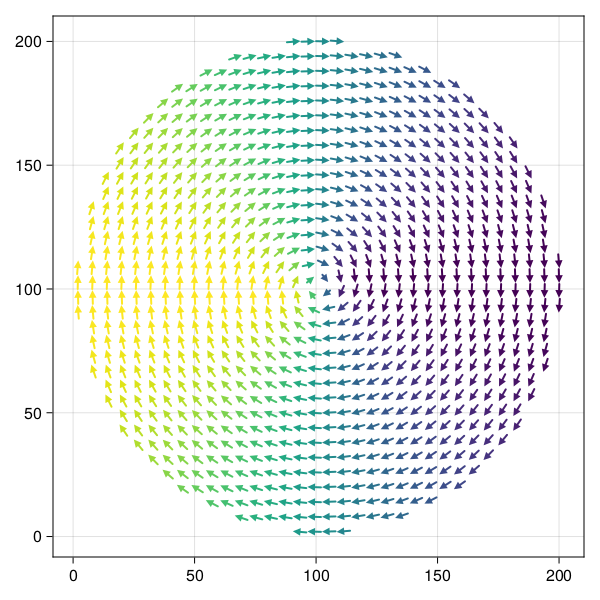

In [7]:
using CairoMakie

function plot_spatial_m()
    m = npzread("vortex.npy")

    nx, ny, nz = 100, 100, 4
    xs = [i*2 for i=1:3:nx]
    ys = [j*2 for j=1:3:ny]

    m = reshape(m, 3, nx, ny, nz)
    mx = m[1,1:3:nx,1:3:ny,1]
    my = m[2,1:3:nx,1:3:ny,1]

    fig = Figure(resolution = (600, 600))
    ax = Axis(fig[1, 1], backgroundcolor = "white")

    lml = sqrt.(mx .^ 2 .+ my .^ 2)
    mx[lml .< 0.1] .= NaN
    my[lml .< 0.1] .= NaN

    arrows!(ax, xs, ys, mx, my, arrowsize = 10, lengthscale = 4, linewidth = 2,
            arrowcolor = vec(my), linecolor =  vec(my), align = :center)


    return fig

end

plot_spatial_m()

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*